# Streaming and exporting simulation products

Large dynamic calculations should not retain every map in accelerator memory.
This notebook streams maps into finite-source photometry, retains three named
epochs, and round-trips typed map and light-curve products. The numerical
calculation uses CUDA and Triton when available.


The package returns typed objects containing Torch tensors and
physical metadata. Its compressed-NPZ helpers preserve the registered grid,
epoch, method, bands, flux units, and provenance. FITS export is also shown
when Astropy is installed.


In [1]:
from pathlib import Path
import platform
import numpy as np
import torch
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available and capabilities.triton_importable
runtime_config = mc.RuntimeConfig(
    profiling="detailed",  # opt in to synchronized component timings
    device="cuda" if use_cuda else "cpu",
    backend="triton" if use_cuda else "auto",
    dtype=torch.float32,
    strict_backend=use_cuda,
    memory_fraction=0.80,
)
print("Platform:", platform.platform())
print("GPU:", capabilities.gpu_name)
print("Selected runtime:", mc.resolve_runtime(runtime_config))
output_directory = Path("microcaustics_tutorial_output")
output_directory.mkdir(exist_ok=True)


Platform: Windows-10-10.0.26200-SP0
GPU: NVIDIA GeForce RTX 5070 Ti
Selected runtime: ResolvedRuntime(device=device(type='cuda'), backend=<Backend.TRITON: 'triton'>, dtype=torch.float32, memory_fraction=0.8, strict_backend=True, torch_compile_mode=None, warn_on_compile=True, profiling=<ProfilingLevel.DETAILED: 'detailed'>, capabilities=RuntimeCapabilities(platform='Windows-10-10.0.26200-SP0', torch_version='2.12.1+cu130', cuda_available=True, cuda_version='13.0', mps_available=False, torch_compile_available=True, triton_importable=True, gpu_name='NVIDIA GeForce RTX 5070 Ti', total_device_memory_bytes=17094475776), fallback_reason=None)


In [2]:
lens_redshift, source_redshift = 0.0395, 1.695
macro = mc.MacroLens(
    convergence=0.391, shear=0.391, shear_angle_deg=141.73,
)
map_times = torch.arange(0.0, 3650.0 + 12.5, 25.0)
flux_times = torch.arange(0.0, 3650.0 + 0.5, 1.0)
trajectory = mc.LinearTrajectory(velocity_uas_per_day=(2.0e-4, -1.0e-4))
source_model = mc.GaussianModel(
    sigma_uas=(0.20, 0.30),
    bands_angstrom={"blue": 4800.0, "red": 7500.0},
    source_grid_shape=1024,
    enclosed_flux_fraction=0.999,
    source_margin=1.05,
)
# Resolve the standalone profile once before reusing it in this export demo.
source = source_model.pixelate(source_redshift=source_redshift, runtime=runtime_config)
population = mc.StellarPopulation.salpeter(
    mean_mass_solar=0.3,
    mass_ratio=100.0,
    kinematics=mc.SkyProjectedKinematics(
        ra_deg=340.126125, dec_deg=3.358611,
        stellar_dispersion_km_s=170.0,
        peculiar_velocity_dispersion_km_s=235.0,
        include_cmb_dipole=True, seed=0,
    ),
)
method = mc.production_ipm_config(rays=10_000_000 if use_cuda else 262_144)
system = mc.MicrolensingSystem(
    lens_redshift=lens_redshift,
    source_redshift=source_redshift,
    H0=70.0,
    Om0=0.3,
    macro=macro,
    source=source,
    stellar_population=population,
    duration_days=3650.0,
    trajectory=trajectory,
    light_loss=0.01,
    safety_scale=1.5,
    seed=0,
    runtime=runtime_config,
)


## Retain and save selected maps

`keep_maps_at_days` copies only the requested epochs into `curve.maps`. Every
other map is consumed by photometry and released. The public save functions
then write those products without notebook-specific serialization code.


In [3]:
selected_times = (0.0, 1825.0, 3650.0)
curve = system.light_curve(
    duration_days=3650, map_cadence_days=25, source_cadence_days=1,
    method=method,
    temporal_batch_size=49, scout_refresh_frames=10,
    keep_maps_at_days=selected_times,
)

saved_paths = [
    mc.save_magnification_map(
        magnification_map, output_directory / f"map_{index:03d}.npz"
    )
    for index, magnification_map in enumerate(curve.maps)
]
mc.save_light_curve(curve, output_directory / "light_curve.npz")
print("Saved maps:", [str(path) for path in saved_paths])
print("Light-curve shape:", tuple(curve.flux.shape))
print("Delivered runtime [s]:", curve.timing.delivered_seconds)
print("Requested base-cell budget:", f"{method.rays:,}")


src\microcaustics\solvers\ipm.py:900: CompilationWarning: Compilation event 1: preparing a new Triton specialization for IPM rasterization on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  _warn_new_triton_ipm_specialization(


src\microcaustics\solvers\ipm.py:1289: CompilationWarning: Compilation event 2: preparing a new Triton specialization for batched IPM rasterization on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  _warn_new_triton_ipm_specialization(


Saved maps: ['microcaustics_tutorial_output\\map_000.npz', 'microcaustics_tutorial_output\\map_001.npz', 'microcaustics_tutorial_output\\map_002.npz']
Light-curve shape: (3651, 2)
Delivered runtime [s]: 5.855744600004982
Requested base-cell budget: 10,000,000


## Reload and inspect saved products

The package reconstructs the map's field of view, center, shape, epoch, and
method, and restores the light curve in physical Jy units.


Stored requested base cells: 10000000
Stored actual base cells: 9998244


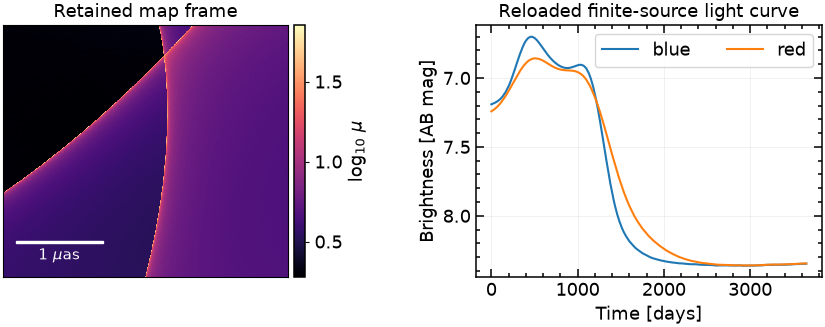

In [4]:
loaded_map = mc.load_magnification_map(saved_paths[0])
loaded_curve = mc.load_light_curve(output_directory / "light_curve.npz")

figure, axes = plt.subplots(1, 2, figsize=(8.8, 3.6))
mcp.plot_magnification_map(loaded_map, ax=axes[0], scale_bar_uas=1.0, show_axes=False)
mcp.plot_light_curve(loaded_curve, ax=axes[1], magnitude=True)
axes[0].set_title("Retained map frame")
axes[1].set_title("Reloaded finite-source light curve")
figure.tight_layout()
figure.savefig(
    output_directory / "streamed_map_and_light_curve.png",
    dpi=220, bbox_inches="tight", facecolor="white",
)
print("Stored requested base cells:", loaded_map.metadata.get("requested_base_cells"))
print("Stored actual base cells:", loaded_map.metadata.get("actual_base_cells"))
assert int(loaded_map.metadata["requested_base_cells"]) == int(method.rays)
assert abs(int(loaded_map.metadata["actual_base_cells"]) - int(method.rays)) / int(method.rays) < 1.0e-3


## Optional FITS export
FITS is useful for astronomy tools and preserves physical registration in standard header keywords. Install the `science` extra to run this cell.

In [5]:
try:
    from astropy.io import fits
except ImportError:
    print('Install microcaustics[science] for FITS export.')
else:
    header = fits.Header()
    header['BUNIT'] = 'magnification'
    header['TIME'] = loaded_map.time_days
    header['CDELT1'] = loaded_map.grid.pixel_scale_uas[1]
    header['CDELT2'] = loaded_map.grid.pixel_scale_uas[0]
    header['CRVAL1'] = loaded_map.grid.center_uas[1]
    header['CRVAL2'] = loaded_map.grid.center_uas[0]
    fits.writeto(
        output_directory / 'map_000.fits', loaded_map.numpy(), header,
        overwrite=True,
    )
    print('Wrote', output_directory / 'map_000.fits')


Wrote microcaustics_tutorial_output\map_000.fits


For very long calculations, keep the observer lightweight and write each selected frame immediately. Use one file per frame or a chunked format such as Zarr/HDF5, record the full numerical configuration alongside the data, and verify available storage before retaining complete map sequences. Light-curve-only runs normally need no map files.